# Install Required Libraries

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pandas numpy

# Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Check TensorFlow Version

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Define Dataset Paths

In [4]:
train_dir = "/content/train data.zip"
valid_dir = "/content/Valid data.zip"
test_dir = "/content/test data.zip"

# Extract the Dataset ZIP Files

In [5]:
import os

print("Files in /content:")
for file in os.listdir("/content"):
    print(file)

Files in /content:
.config
best_efficientnetb0.keras
best_custom_cnn.h5
mobilenetv2_final.keras
train data.zip
Valid data.zip
test
test data.zip
best_mobilenetv2.keras
custom_cnn_final.keras
valid
train
sample_data


# Check the three files

In [6]:
import os

files = [
    "/content/train data.zip",
    "/content/Valid data.zip",
    "/content/test data.zip"
]

for file in files:
    print("\nFile:", file)
    print("Exists:", os.path.exists(file))

    if os.path.exists(file):
        print("Size:", os.path.getsize(file), "bytes")


File: /content/train data.zip
Exists: True
Size: 54920924 bytes

File: /content/Valid data.zip
Exists: True
Size: 16081527 bytes

File: /content/test data.zip
Exists: True
Size: 7946981 bytes


# Test the ZIP files

In [7]:
import zipfile

files = [
    "/content/train data.zip",
    "/content/Valid data.zip",
    "/content/test data.zip"
]

for file in files:
    print("\nChecking:", file)

    if zipfile.is_zipfile(file):
        print("Valid ZIP file")
    else:
        print("NOT a valid ZIP file")


Checking: /content/train data.zip
Valid ZIP file

Checking: /content/Valid data.zip
Valid ZIP file

Checking: /content/test data.zip
Valid ZIP file


In [8]:
import zipfile
import os

datasets = {
    "/content/train data.zip": "/content/train",
    "/content/Valid data.zip": "/content/valid",
    "/content/test data.zip": "/content/test"
}

for zip_path, extract_path in datasets.items():

    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extracted:", zip_path)

print("\nAll datasets extracted successfully.")

Extracted: /content/train data.zip
Extracted: /content/Valid data.zip
Extracted: /content/test data.zip

All datasets extracted successfully.


# Check the extracted structure

In [9]:
print("TRAIN:")
print(os.listdir("/content/train"))

print("\nVALIDATION:")
print(os.listdir("/content/valid"))

print("\nTEST:")
print(os.listdir("/content/test"))

TRAIN:
['train']

VALIDATION:
['valid']

TEST:
['test']


# Check the Inner Dataset Structure

In [10]:
import os

print("TRAIN:")
print(os.listdir("/content/train/train"))

print("\nVALIDATION:")
print(os.listdir("/content/valid/valid"))

print("\nTEST:")
print(os.listdir("/content/test/test"))

TRAIN:
['pituitary', 'meningioma', 'no_tumor', 'glioma', '_classes.csv']

VALIDATION:
['pituitary', 'meningioma', 'no_tumor', 'glioma', '_classes.csv']

TEST:
['pituitary', 'meningioma', 'no_tumor', 'glioma', '_classes.csv']


In [11]:
train_dir = "/content/train/train"
valid_dir = "/content/valid/valid"
test_dir = "/content/test/test"

print("Training path:", train_dir)
print("Validation path:", valid_dir)
print("Testing path:", test_dir)

Training path: /content/train/train
Validation path: /content/valid/valid
Testing path: /content/test/test


# Check Number of Images in Each Class

In [12]:
# Define the correct dataset paths

train_dir = "/content/train/train"
valid_dir = "/content/valid/valid"
test_dir = "/content/test/test"

print("Training path:", train_dir)
print("Validation path:", valid_dir)
print("Testing path:", test_dir)

Training path: /content/train/train
Validation path: /content/valid/valid
Testing path: /content/test/test


# Check Number of Images in Each Class

In [13]:
# Check Number of Images in Each Class

import os

classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

for dataset_name, dataset_path in [
    ("TRAINING", train_dir),
    ("VALIDATION", valid_dir),
    ("TESTING", test_dir)
]:

    print("\n" + dataset_name)
    print("-" * 40)

    for class_name in classes:

        class_path = os.path.join(dataset_path, class_name)

        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {image_count}")


TRAINING
----------------------------------------
glioma: 564
meningioma: 358
pituitary: 438
no_tumor: 335

VALIDATION
----------------------------------------
glioma: 161
meningioma: 124
pituitary: 118
no_tumor: 99

TESTING
----------------------------------------
glioma: 80
meningioma: 63
pituitary: 54
no_tumor: 49


# Visualise Sample MRI Images

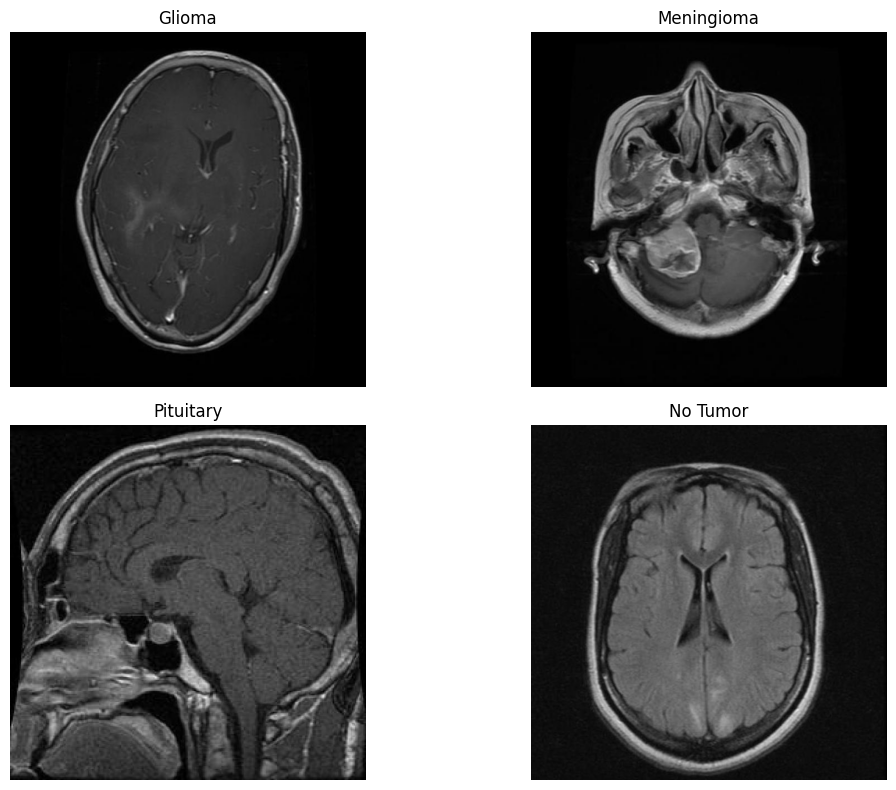

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("_", " ").title())
    plt.axis("off")

plt.tight_layout()
plt.show()

# Create Image Count DataFrame

In [15]:
import pandas as pd

count_df = pd.DataFrame({
    "Training": {
        "glioma": 564,
        "meningioma": 358,
        "pituitary": 438,
        "no_tumor": 335
    },
    "Validation": {
        "glioma": 161,
        "meningioma": 124,
        "pituitary": 118,
        "no_tumor": 99
    },
    "Testing": {
        "glioma": 80,
        "meningioma": 63,
        "pituitary": 54,
        "no_tumor": 49
    }
})

count_df

,Training,Validation,Testing
glioma,564,161,80
meningioma,358,124,63
pituitary,438,118,54
no_tumor,335,99,49


# Calculate Total Images

In [16]:
print("Total Training Images:",
      count_df["Training"].sum())

print("Total Validation Images:",
      count_df["Validation"].sum())

print("Total Testing Images:",
      count_df["Testing"].sum())

print("Total Dataset Images:",
      count_df.sum().sum())

Total Training Images: 1695
Total Validation Images: 502
Total Testing Images: 246
Total Dataset Images: 2443


# Check Image Dimensions

In [17]:
for class_name in classes:

    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    print(
        class_name,
        "-> Size:", image.size,
        "| Format:", image.format,
        "| Mode:", image.mode
    )

glioma -> Size: (640, 640) | Format: JPEG | Mode: RGB
meningioma -> Size: (640, 640) | Format: JPEG | Mode: RGB
pituitary -> Size: (640, 640) | Format: JPEG | Mode: RGB
no_tumor -> Size: (640, 640) | Format: JPEG | Mode: RGB


# Define Image Parameters

In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)

Image Size: (224, 224)
Batch Size: 32
Number of Classes: 4


# Create Training Data Generator

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 1695 images belonging to 4 classes.


# Create Validation Data Generator

In [20]:
valid_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 502 images belonging to 4 classes.


# Create Test Data Generator

In [21]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 246 images belonging to 4 classes.


# Verify Data Generators

In [22]:
print("Training images:", train_generator.samples)
print("Validation images:", valid_generator.samples)
print("Testing images:", test_generator.samples)

print("\nClass Mapping:")
print(train_generator.class_indices)

Training images: 1695
Validation images: 502
Testing images: 246

Class Mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


# Check One Batch

In [23]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


# Visualise Augmented Images

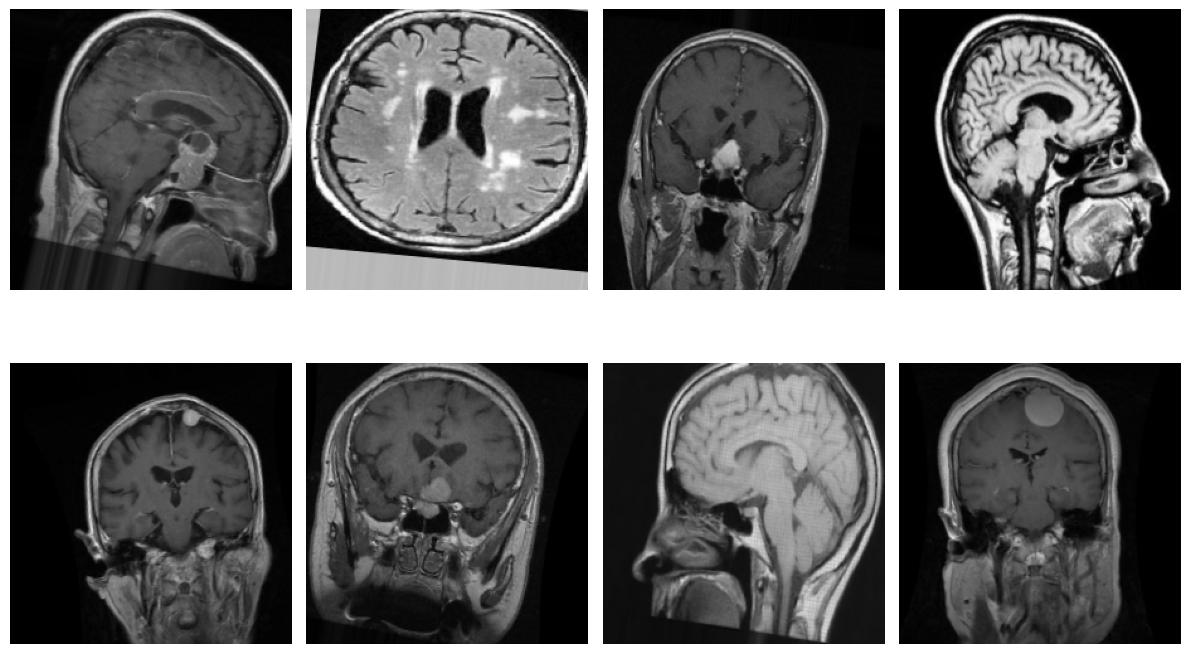

In [24]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Build Custom CNN Model

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

custom_cnn = Sequential([

    # Convolution Block 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Block 2
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Block 3
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Block 4
    Conv2D(
        256,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Classification Layers
    Flatten(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Display CNN Architecture

In [26]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,804 (37.49 MB)

 Trainable params: 9,827,844 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile Custom CNN

In [27]:
custom_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


# Create Training Callbacks

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_custom_cnn.h5",
    monitor="val_loss",
    save_best_only=True
)

# Train Custom CNN

In [29]:
# Train Custom CNN

history = custom_cnn.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5228 - loss: 9.2712

53/53 ━━━━━━━━━━━━━━━━━━━━ 335s 6s/step - accuracy: 0.5658 - loss: 5.5456 - val_accuracy: 0.2809 - val_loss: 10.3054
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.5870 - loss: 1.2585 - val_accuracy: 0.2550 - val_loss: 10.8760
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.6313 - loss: 1.0243 - val_accuracy: 0.1375 - val_loss: 11.5355
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 326s 6s/step - accuracy: 0.6230 - loss: 0.9964 - val_accuracy: 0.1972 - val_loss: 16.4262
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6501 - loss: 0.9455

53/53 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.6507 - loss: 0.9171 - val_accuracy: 0.2888 - val_loss: 6.1578
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6271 - loss: 0.9755

53/53 ━━━━━━━━━━━━━━━━━━━━ 325s 6s/step - accuracy: 0.6348 - loss: 0.9200 - val_accuracy: 0.3028 - val_loss: 4.8568
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 382s 6s/step - accuracy: 0.6637 - loss: 0.8735 - val_accuracy: 0.1912 - val_loss: 17.4066
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6858 - loss: 0.8632

53/53 ━━━━━━━━━━━━━━━━━━━━ 328s 6s/step - accuracy: 0.6643 - loss: 0.8814 - val_accuracy: 0.5817 - val_loss: 1.0408
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6184 - loss: 0.9064

53/53 ━━━━━━━━━━━━━━━━━━━━ 324s 6s/step - accuracy: 0.6242 - loss: 0.9292 - val_accuracy: 0.6614 - val_loss: 0.9538
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6727 - loss: 0.9378

53/53 ━━━━━━━━━━━━━━━━━━━━ 322s 6s/step - accuracy: 0.6796 - loss: 0.8200 - val_accuracy: 0.7251 - val_loss: 0.6958


# Plot Training and Validation Accuracy

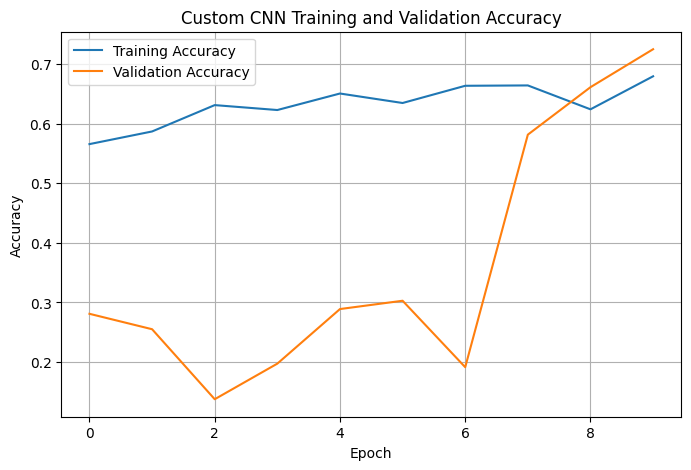

In [30]:
# Plot Training and Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot Training and Validation Loss

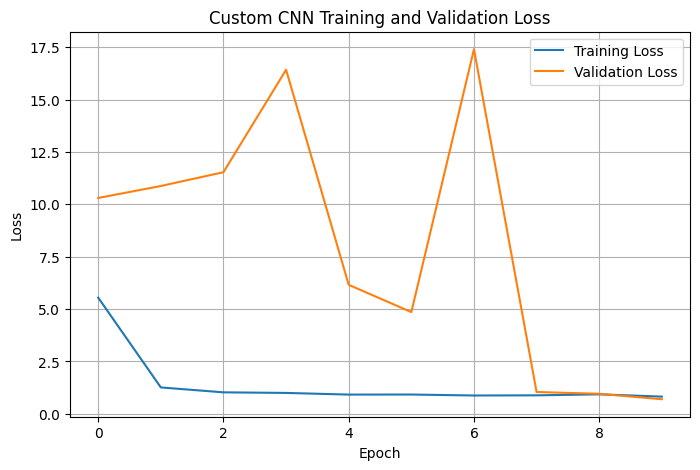

In [31]:
# Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Find the Best Validation Accuracy

In [32]:
# Find Best Validation Accuracy

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_epoch = (
    history.history["val_accuracy"].index(
        best_val_accuracy
    ) + 1
)

print(
    "Best Validation Accuracy:",
    round(best_val_accuracy * 100, 2),
    "%"
)

print(
    "Best Epoch:",
    best_epoch
)

Best Validation Accuracy: 72.51 %
Best Epoch: 10


# Evaluate Custom CNN on Test Dataset

In [33]:
# Evaluate Custom CNN on Test Dataset

test_loss, test_accuracy = custom_cnn.evaluate(
    test_generator
)

print("Test Loss:", round(test_loss, 4))
print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7480 - loss: 0.6352
Test Loss: 0.6352
Test Accuracy: 74.8 %


# Generate Test Predictions

In [34]:
# Generate Predictions on Test Dataset

import numpy as np

test_generator.reset()

predictions = custom_cnn.predict(
    test_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

print("Predictions generated successfully.")
print("Number of predictions:", len(predicted_classes))

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Predictions generated successfully.
Number of predictions: 246


# Get Class Names

In [35]:
# Get Class Names

class_names = list(
    test_generator.class_indices.keys()
)

print("Class Names:")
print(class_names)

Class Names:
['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Generate Classification Report

In [36]:
# Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      glioma     0.8132    0.9250    0.8655        80
  meningioma     0.8148    0.3492    0.4889        63
    no_tumor     0.7447    0.7143    0.7292        49
   pituitary     0.6543    0.9815    0.7852        54

    accuracy                         0.7480       246
   macro avg     0.7568    0.7425    0.7172       246
weighted avg     0.7651    0.7480    0.7243       246



# Confusion Matrix

In [37]:
# Create Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[74  2  0  4]
 [15 22 12 14]
 [ 1  3 35 10]
 [ 1  0  0 53]]


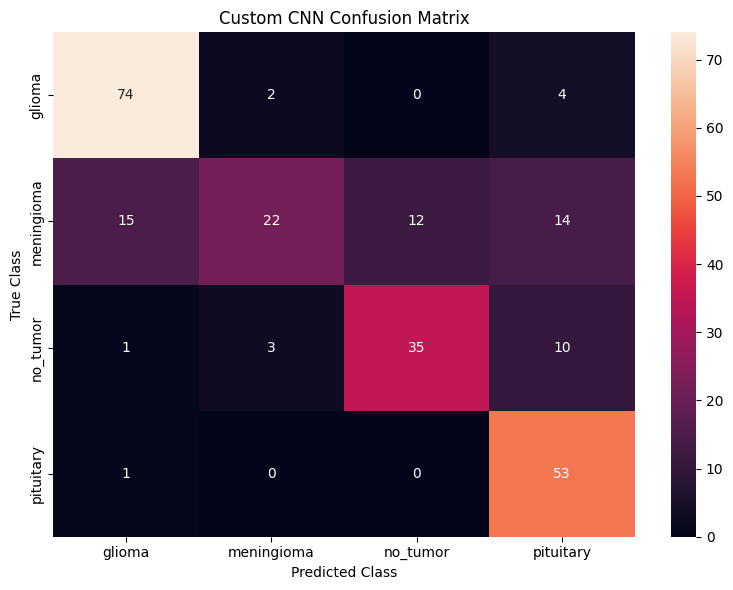

In [38]:
# Visualise Confusion Matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

# Save the Custom CNN

In [39]:
# Save Final Custom CNN

custom_cnn.save(
    "custom_cnn_final.keras"
)

print("Custom CNN saved successfully.")

Custom CNN saved successfully.


# Transfer Learning

# Create MobileNetV2 Data Generators

In [40]:
# MobileNetV2 Data Preprocessing

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

mobile_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

mobile_valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

mobile_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create MobileNetV2 Training Generator

In [41]:
mobile_train_generator = mobile_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 1695 images belonging to 4 classes.


# Create MobileNetV2 Validation Generator

In [42]:
mobile_valid_generator = mobile_valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 502 images belonging to 4 classes.


# Create MobileNetV2 Test Generator

In [43]:
mobile_test_generator = mobile_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 246 images belonging to 4 classes.


# Verify the Generators

In [44]:
print("Training images:", mobile_train_generator.samples)
print("Validation images:", mobile_valid_generator.samples)
print("Testing images:", mobile_test_generator.samples)

print("\nClass mapping:")
print(mobile_train_generator.class_indices)

Training images: 1695
Validation images: 502
Testing images: 246

Class mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


# Load Pretrained MobileNetV2

In [45]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


# Freeze the Pretrained Layers

In [46]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

Trainable: False


# Build the MobileNetV2 Classifier

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compile MobileNetV2

In [48]:
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 compiled successfully.")

MobileNetV2 compiled successfully.


# Create MobileNetV2 Callbacks

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

mobilenet_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mobilenet_checkpoint = ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True
)

# Train MobileNetV2

In [50]:
mobilenet_history = mobilenet_model.fit(
    mobile_train_generator,
    validation_data=mobile_valid_generator,
    epochs=10,
    callbacks=[
        mobilenet_early_stopping,
        mobilenet_checkpoint
    ]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.6956 - loss: 0.7994 - val_accuracy: 0.8486 - val_loss: 0.4449
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8395 - loss: 0.4133 - val_accuracy: 0.8167 - val_loss: 0.4774
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8655 - loss: 0.3681 - val_accuracy: 0.8506 - val_loss: 0.4306
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8844 - loss: 0.3183 - val_accuracy: 0.8765 - val_loss: 0.3461
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8897 - loss: 0.2911 - val_accuracy: 0.8865 - val_loss: 0.3590
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8985 - loss: 0.2710 - val_accuracy: 0.8924 - val_loss: 0.3421
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9086 - loss: 0.2514 - val_accuracy: 0.8466 - val_loss: 0.4031
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9174 - loss: 0.2299 - val_accuracy: 0.8805 - v

# Plot MobileNetV2 Accuracy

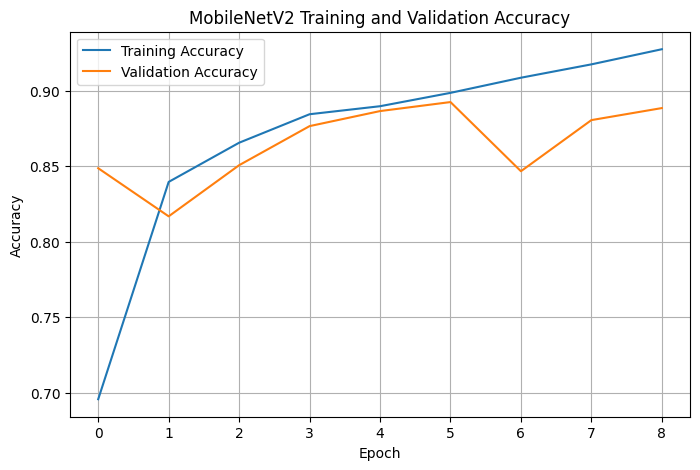

In [51]:
# MobileNetV2 Training and Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot MobileNetV2 Loss

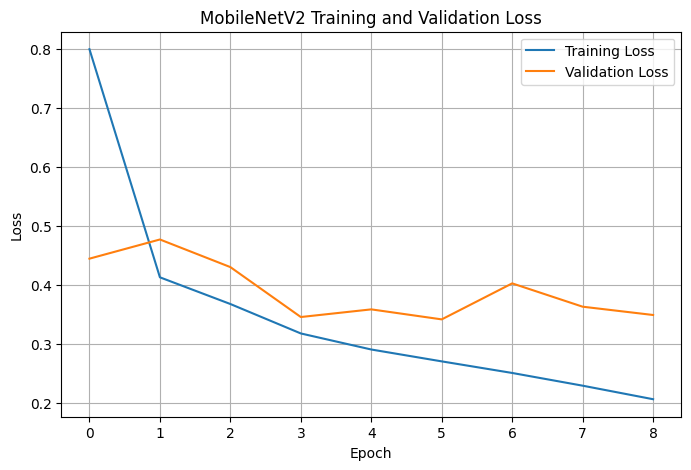

In [52]:
# MobileNetV2 Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Find Best Validation Accuracy

In [53]:
# Find Best MobileNetV2 Validation Accuracy

best_mobile_val_accuracy = max(
    mobilenet_history.history["val_accuracy"]
)

best_mobile_epoch = (
    mobilenet_history.history["val_accuracy"].index(
        best_mobile_val_accuracy
    ) + 1
)

print(
    "Best Validation Accuracy:",
    round(best_mobile_val_accuracy * 100, 2),
    "%"
)

print(
    "Best Epoch:",
    best_mobile_epoch
)

Best Validation Accuracy: 89.24 %
Best Epoch: 6


# Evaluate MobileNetV2 on Test Data

In [54]:
# Evaluate MobileNetV2 on Test Dataset

mobile_test_loss, mobile_test_accuracy = mobilenet_model.evaluate(
    mobile_test_generator
)

print(
    "MobileNetV2 Test Loss:",
    round(mobile_test_loss, 4)
)

print(
    "MobileNetV2 Test Accuracy:",
    round(mobile_test_accuracy * 100, 2),
    "%"
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8821 - loss: 0.3309
MobileNetV2 Test Loss: 0.3309
MobileNetV2 Test Accuracy: 88.21 %


# Generate Test Predictions

In [55]:
# Generate MobileNetV2 Predictions

import numpy as np

mobile_test_generator.reset()

mobile_predictions = mobilenet_model.predict(
    mobile_test_generator
)

mobile_predicted_classes = np.argmax(
    mobile_predictions,
    axis=1
)

mobile_true_classes = mobile_test_generator.classes

print("Predictions generated successfully.")
print(
    "Number of predictions:",
    len(mobile_predicted_classes)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Predictions generated successfully.
Number of predictions: 246


# Get Class Names

In [56]:
# Get Class Names

mobile_class_names = list(
    mobile_test_generator.class_indices.keys()
)

print("Class Names:")
print(mobile_class_names)

Class Names:
['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Classification Report

In [57]:
# MobileNetV2 Classification Report

from sklearn.metrics import classification_report

mobile_report = classification_report(
    mobile_true_classes,
    mobile_predicted_classes,
    target_names=mobile_class_names,
    digits=4
)

print(mobile_report)

              precision    recall  f1-score   support

      glioma     0.9157    0.9500    0.9325        80
  meningioma     0.8519    0.7302    0.7863        63
    no_tumor     0.9130    0.8571    0.8842        49
   pituitary     0.8413    0.9815    0.9060        54

    accuracy                         0.8821       246
   macro avg     0.8805    0.8797    0.8773       246
weighted avg     0.8825    0.8821    0.8796       246



# Confusion Matrix

In [58]:
# MobileNetV2 Confusion Matrix

from sklearn.metrics import confusion_matrix

mobile_cm = confusion_matrix(
    mobile_true_classes,
    mobile_predicted_classes
)

print(mobile_cm)

[[76  4  0  0]
 [ 4 46  4  9]
 [ 2  4 42  1]
 [ 1  0  0 53]]


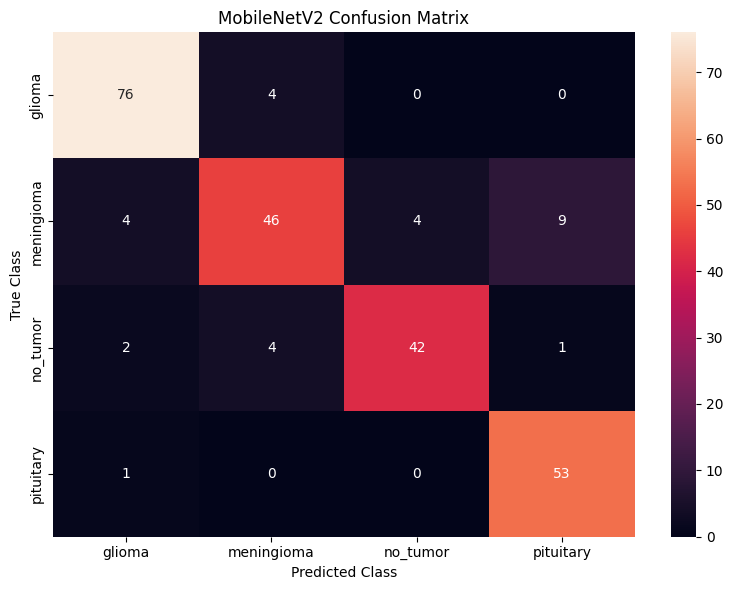

In [59]:
# Visualise MobileNetV2 Confusion Matrix

import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    mobile_cm,
    annot=True,
    fmt="d",
    xticklabels=mobile_class_names,
    yticklabels=mobile_class_names
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

# Save MobileNetV2

In [60]:
# Save MobileNetV2

mobilenet_model.save(
    "mobilenetv2_final.keras"
)

print("MobileNetV2 saved successfully.")

MobileNetV2 saved successfully.


# Transfer-learning model: EfficientNetB0

# Create EfficientNetB0 Data Generators

In [61]:
# EfficientNetB0 Data Preprocessing

from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

efficient_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

efficient_valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

efficient_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

$ Create Training Generator

In [62]:
# EfficientNetB0 Training Generator

efficient_train_generator = efficient_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 1695 images belonging to 4 classes.


# Create Validation Generator

In [63]:
# EfficientNetB0 Validation Generator

efficient_valid_generator = efficient_valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 502 images belonging to 4 classes.


# Create Test Generator

In [64]:
# EfficientNetB0 Test Generator

efficient_test_generator = efficient_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 246 images belonging to 4 classes.


# Verify Dataset

In [65]:
# Verify EfficientNetB0 Dataset

print("Training images:", efficient_train_generator.samples)
print("Validation images:", efficient_valid_generator.samples)
print("Testing images:", efficient_test_generator.samples)

print("\nClass mapping:")
print(efficient_train_generator.class_indices)

Training images: 1695
Validation images: 502
Testing images: 246

Class mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


# Load Pretrained EfficientNetB0

In [66]:
# Load Pretrained EfficientNetB0

from tensorflow.keras.applications import EfficientNetB0

efficient_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("EfficientNetB0 loaded successfully.")

EfficientNetB0 loaded successfully.


# Freeze Pretrained Layers

In [67]:
# Freeze EfficientNetB0 Base Layers

efficient_base.trainable = False

print("Trainable:", efficient_base.trainable)

Trainable: False


# Build EfficientNetB0 Classifier

In [68]:
# Build EfficientNetB0 Classification Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

efficient_model = Sequential([

    efficient_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

efficient_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile EfficientNetB0

In [69]:
# Compile EfficientNetB0

efficient_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


# Create Callbacks

In [70]:
# EfficientNetB0 Training Callbacks

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

efficient_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

efficient_checkpoint = ModelCheckpoint(
    "best_efficientnetb0.keras",
    monitor="val_loss",
    save_best_only=True
)

# Train EfficientNetB0

In [71]:
# Train EfficientNetB0

efficient_history = efficient_model.fit(
    efficient_train_generator,
    validation_data=efficient_valid_generator,
    epochs=10,
    callbacks=[
        efficient_early_stopping,
        efficient_checkpoint
    ]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.6832 - loss: 0.7858 - val_accuracy: 0.8068 - val_loss: 0.4941
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.8165 - loss: 0.4645 - val_accuracy: 0.8625 - val_loss: 0.3875
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8401 - loss: 0.4129 - val_accuracy: 0.8486 - val_loss: 0.3936
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8678 - loss: 0.3567 - val_accuracy: 0.8406 - val_loss: 0.4066
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.8791 - loss: 0.3177 - val_accuracy: 0.8685 - val_loss: 0.3553
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.8956 - loss: 0.2892 - val_accuracy: 0.8865 - val_loss: 0.3029
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.9032 - loss: 0.2720 - val_accuracy: 0.8765 - val_loss: 0.3207
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9133 - loss: 0.2502 - val_accuracy: 0.8665 - v

# Plot EfficientNetB0 Accuracy

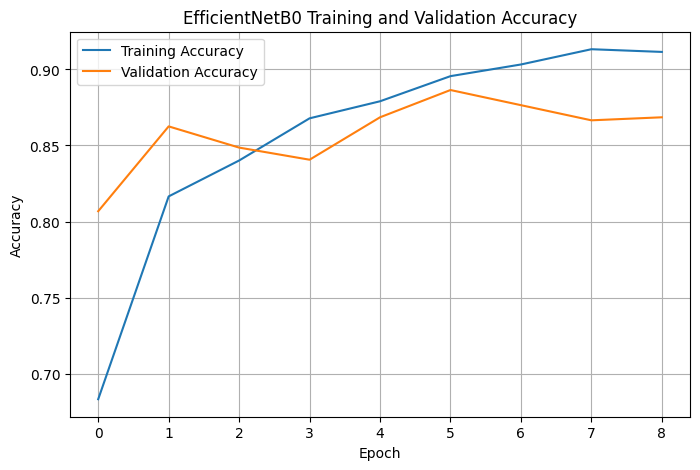

In [72]:
# EfficientNetB0 Training and Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    efficient_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    efficient_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot EfficientNetB0 Loss

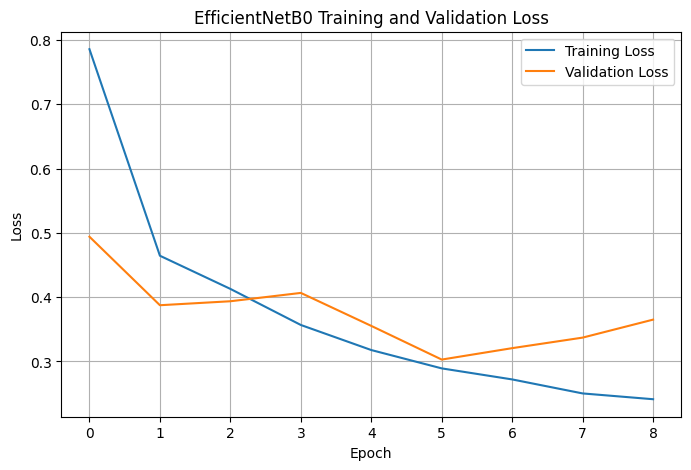

In [73]:
# EfficientNetB0 Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    efficient_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    efficient_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Find Best Validation Accuracy

In [74]:
# Find Best EfficientNetB0 Validation Accuracy

best_efficient_val_accuracy = max(
    efficient_history.history["val_accuracy"]
)

best_efficient_epoch = (
    efficient_history.history["val_accuracy"].index(
        best_efficient_val_accuracy
    ) + 1
)

print(
    "Best Validation Accuracy:",
    round(best_efficient_val_accuracy * 100, 2),
    "%"
)

print(
    "Best Epoch:",
    best_efficient_epoch
)

Best Validation Accuracy: 88.65 %
Best Epoch: 6


# Evaluate on Test Dataset

In [75]:
# Evaluate EfficientNetB0 on Test Dataset

efficient_test_loss, efficient_test_accuracy = efficient_model.evaluate(
    efficient_test_generator
)

print(
    "EfficientNetB0 Test Loss:",
    round(efficient_test_loss, 4)
)

print(
    "EfficientNetB0 Test Accuracy:",
    round(efficient_test_accuracy * 100, 2),
    "%"
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8862 - loss: 0.3172
EfficientNetB0 Test Loss: 0.3172
EfficientNetB0 Test Accuracy: 88.62 %


# Generate Predictions

In [76]:
# Generate EfficientNetB0 Predictions

import numpy as np

efficient_test_generator.reset()

efficient_predictions = efficient_model.predict(
    efficient_test_generator
)

efficient_predicted_classes = np.argmax(
    efficient_predictions,
    axis=1
)

efficient_true_classes = efficient_test_generator.classes

print("Predictions generated successfully.")
print(
    "Number of predictions:",
    len(efficient_predicted_classes)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
Predictions generated successfully.
Number of predictions: 246


# Get Class Names

In [77]:
# Get EfficientNetB0 Class Names

efficient_class_names = list(
    efficient_test_generator.class_indices.keys()
)

print("Class Names:")
print(efficient_class_names)

Class Names:
['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Classification Report

In [78]:
# EfficientNetB0 Classification Report

from sklearn.metrics import classification_report

efficient_report = classification_report(
    efficient_true_classes,
    efficient_predicted_classes,
    target_names=efficient_class_names,
    digits=4
)

print(efficient_report)

              precision    recall  f1-score   support

      glioma     0.9231    0.9000    0.9114        80
  meningioma     0.7794    0.8413    0.8092        63
    no_tumor     0.9512    0.7959    0.8667        49
   pituitary     0.9153    1.0000    0.9558        54

    accuracy                         0.8862       246
   macro avg     0.8922    0.8843    0.8857       246
weighted avg     0.8902    0.8862    0.8860       246



# Confusion Matrix

In [79]:
# EfficientNetB0 Confusion Matrix

from sklearn.metrics import confusion_matrix

efficient_cm = confusion_matrix(
    efficient_true_classes,
    efficient_predicted_classes
)

print(efficient_cm)

[[72  8  0  0]
 [ 3 53  2  5]
 [ 3  7 39  0]
 [ 0  0  0 54]]


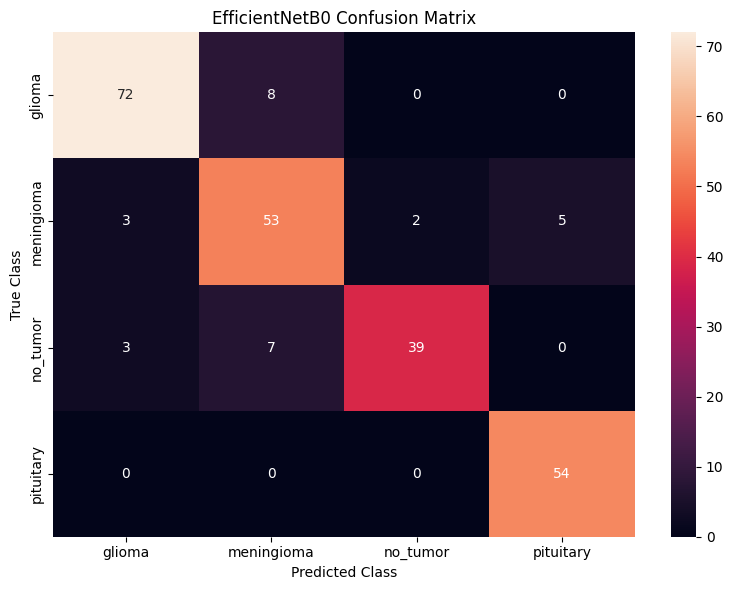

In [80]:
# Visualise EfficientNetB0 Confusion Matrix

import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    efficient_cm,
    annot=True,
    fmt="d",
    xticklabels=efficient_class_names,
    yticklabels=efficient_class_names
)

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

#  Save EfficientNetB0

In [81]:
# Save EfficientNetB0

efficient_model.save(
    "efficientnetb0_final.keras"
)

print("EfficientNetB0 saved successfully.")

EfficientNetB0 saved successfully.


# Calculate Metrics for All Three Models

In [82]:
# Model Comparison Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# Custom CNN metrics
custom_accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

custom_precision = precision_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

custom_recall = recall_score(
    true_classes,
    predicted_classes,
    average="weighted"
)

custom_f1 = f1_score(
    true_classes,
    predicted_classes,
    average="weighted"
)


# MobileNetV2 metrics
mobile_accuracy = accuracy_score(
    mobile_true_classes,
    mobile_predicted_classes
)

mobile_precision = precision_score(
    mobile_true_classes,
    mobile_predicted_classes,
    average="weighted"
)

mobile_recall = recall_score(
    mobile_true_classes,
    mobile_predicted_classes,
    average="weighted"
)

mobile_f1 = f1_score(
    mobile_true_classes,
    mobile_predicted_classes,
    average="weighted"
)


# EfficientNetB0 metrics
efficient_accuracy = accuracy_score(
    efficient_true_classes,
    efficient_predicted_classes
)

efficient_precision = precision_score(
    efficient_true_classes,
    efficient_predicted_classes,
    average="weighted"
)

efficient_recall = recall_score(
    efficient_true_classes,
    efficient_predicted_classes,
    average="weighted"
)

efficient_f1 = f1_score(
    efficient_true_classes,
    efficient_predicted_classes,
    average="weighted"
)

print("Metrics calculated successfully.")

Metrics calculated successfully.


# Create Final Model Comparison Table

In [83]:
# Create Model Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Accuracy": [
        custom_accuracy,
        mobile_accuracy,
        efficient_accuracy
    ],

    "Precision": [
        custom_precision,
        mobile_precision,
        efficient_precision
    ],

    "Recall": [
        custom_recall,
        mobile_recall,
        efficient_recall
    ],

    "F1-Score": [
        custom_f1,
        mobile_f1,
        efficient_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.747967,0.765085,0.747967,0.724264
1,MobileNetV2,0.882114,0.882469,0.882114,0.879630
2,EfficientNetB0,0.886179,0.890173,0.886179,0.886040


# Display Percentages

In [84]:
# Display Model Comparison in Percentage

comparison_display = comparison_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2)

comparison_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,74.80,76.51,74.80,72.43
1,MobileNetV2,88.21,88.25,88.21,87.96
2,EfficientNetB0,88.62,89.02,88.62,88.60


# Identify the Best Model

In [85]:
# Select Best Model Based on F1-Score

best_model_row = comparison_df.loc[
    comparison_df["F1-Score"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print(
    "Best F1-Score:",
    round(best_model_row["F1-Score"] * 100, 2),
    "%"
)

Best Model: EfficientNetB0
Best F1-Score: 88.6 %


# Compare Models Visually

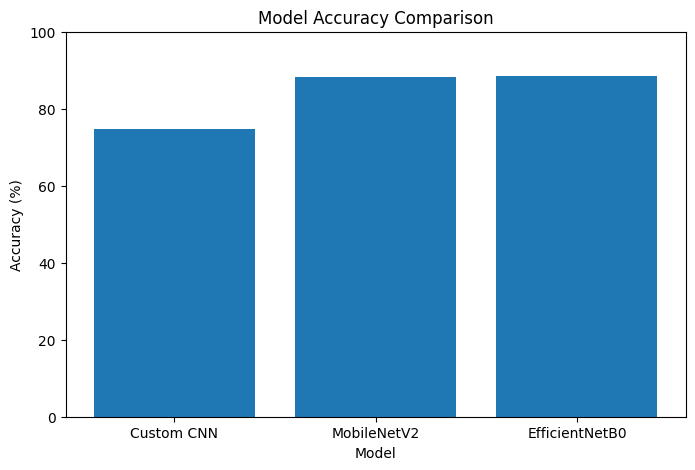

In [86]:
# Compare Model Accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_display["Model"],
    comparison_display["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

# Compare F1-Scores

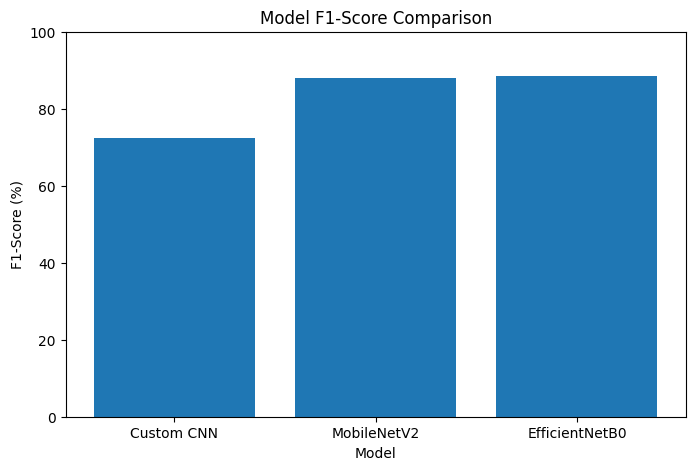

In [87]:
# Compare Model F1-Scores

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_display["Model"],
    comparison_display["F1-Score"]
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score (%)")
plt.ylim(0, 100)

plt.show()

# Save Comparison Results

In [88]:
# Save Model Comparison Results

comparison_display.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# Save the Best Model Information

In [89]:
# Save Best Model Information

best_model_name = best_model_row["Model"]

print("Selected Final Model:", best_model_name)

Selected Final Model: EfficientNetB0


# Load the Best EfficientNetB0

In [90]:
# Load Best EfficientNetB0

from tensorflow.keras.models import load_model

final_model = load_model(
    "best_efficientnetb0.keras"
)

print("Best EfficientNetB0 loaded successfully.")

Best EfficientNetB0 loaded successfully.


# Define Class Names

In [91]:
# Define Tumor Classes

class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


# Create Final Prediction Function

In [92]:
# Final MRI Prediction Function

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

def predict_brain_tumor(image_path):

    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    image_array = preprocess_input(
        image_array
    )

    prediction = final_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = prediction[0][
        predicted_index
    ] * 100

    return predicted_class, confidence

# Test the Prediction Function

In [94]:
# Test Final Model Prediction

import os

sample_image = None

for class_name in class_names:

    class_path = os.path.join(
        test_dir,
        class_name
    )

    if os.path.exists(class_path):

        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        if images:
            sample_image = os.path.join(
                class_path,
                images[0]
            )
            break

print("Sample image:", sample_image)

predicted_class, confidence = predict_brain_tumor(
    sample_image
)

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Sample image: /content/test/test/glioma/Tr-gl_0486_jpg.rf.e6b7a5aa7d3600d0ce2f1997e3ac5dd9.jpg
Predicted Class: glioma
Confidence: 90.54 %


# Display the MRI and Prediction

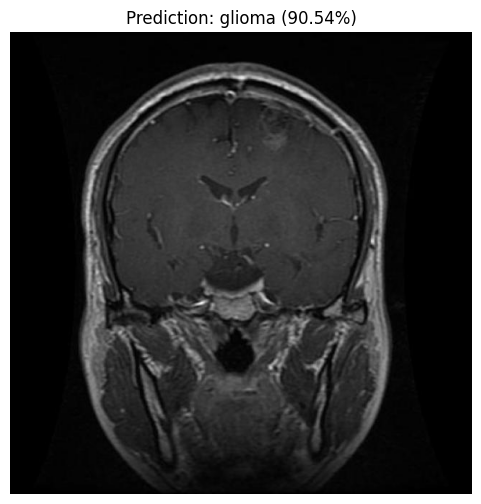

In [95]:
# Display Sample Prediction

import matplotlib.pyplot as plt
from PIL import Image

image = Image.open(sample_image)

plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.title(
    f"Prediction: {predicted_class} "
    f"({confidence:.2f}%)"
)

plt.axis("off")
plt.show()